# The Lovelock tensors of the author's metric with the generalized Kronecker delta (GKD)

*A Revision notebook of the repository Dirac_claude. It runs the Revision Rust program
`Revision/gkd_lovelock/code` (the crate `lovelock_gkd`) and checks what it prints and writes against
the committed Revision record in `Revision/gkd_lovelock/results/`.*

## 1. What this notebook computes

The author gave a metric (a rule for measuring lengths and times) for the primordial gravitational
field in eight dimensions. Gravity theories of the Lovelock family use, for each order k, one
tensor built from the curvature of the metric: k = 1 is Einstein's tensor, k = 2 the
Gauss-Bonnet tensor, k = 3 the third-order Lovelock tensor. In eight dimensions these three are
the only non-zero ones.

This notebook

1. builds the Revision Rust program with `cargo build --release` and lets it recite its own
   configuration (the metric exactly as the author wrote it, the coordinates, the curvature
   convention, the Lovelock formula and the definition of the GKD);
2. re-checks the generalized Kronecker delta in Python, exhaustively for index lists of length
   1, 2 and 3 over eight values, against the literal determinant that defines it;
3. runs the program once more (about 15 seconds): it computes, exactly and from the metric
   alone, the Christoffel symbols, the Riemann tensor and the Lovelock tensors of order
   k = 1, 2, 3, runs its 19 checks and writes four result files into a scratch output folder
   (never over the committed record);
4. shows every non-zero component in tables and re-checks three identities exactly in Python
   (the trace identity, the normalised k = 1 tensor equals Einstein's tensor, and the density
   form of the tensors);
5. compares the four new files byte for byte with the committed record and quotes the check
   counts of the five committed reports exactly as their JSON files give them;
6. draws three teaching figures;
7. ends with what it showed and what it did not show.

Every number printed comes either from the program run in this notebook or from the notebook's own
computation; where the two overlap with the committed record, an `assert` names the record file
and the check. The notebook stops with an error if any check fails.

## 2. How to run this notebook

These instructions assume a computer on which nothing has been installed yet. Type each command
into a terminal exactly as printed, one line at a time, and press Enter after each line. A
*terminal* is the window in which you type commands: on Windows 11 the app **Windows PowerShell**
(or **Terminal**), on macOS the app **Terminal** (shell zsh), on Linux any terminal (shell bash).

What you need: Git, Python 3.12 or newer (this notebook was built with Python 3.14.5), the Rust
toolchain (`cargo`), about 2 GB of free disk space and an internet connection for the
installation. The Python packages are pinned in `Revision/notebooks/requirements.txt`:
numpy 2.4.6, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2,
ipykernel 7.1.0 and nbconvert 7.16.6. The notebook does not need WolframScript, sympy or scipy.

### 2.1 Windows 11 (PowerShell)

1. Install Git from https://git-scm.com/download/win (the default choices are fine).
2. Install Python from https://www.python.org/downloads/ . In the installer's first window tick
   **Add python.exe to PATH**, then click **Install Now**.
3. Install Rust from https://rustup.rs : download and run `rustup-init.exe`. If it says that the
   Visual Studio C++ Build Tools are missing, let it install them (Rust needs their linker), then
   choose the default installation.
4. Close PowerShell, open a new one, and check the three tools (each prints a version number):

```text
git --version
python --version
cargo --version
```

5. Fetch the repository and enter it:

```text
cd $HOME
git clone https://github.com/once-ere/Dirac_claude.git
cd Dirac_claude
```

6. Create a private Python environment OUTSIDE the repository (so that nothing is installed
   system-wide and nothing is written into the repository), and install the pinned packages into it:

```text
python -m venv $HOME\venvs\revision-nb
$PY = "$HOME\venvs\revision-nb\Scripts\python.exe"
& $PY -m pip install --upgrade pip
& $PY -m pip install -r Revision/notebooks/requirements.txt
```

7. Start JupyterLab with this notebook (a browser window opens):

```text
& $PY -m jupyterlab Revision/notebooks/lovelock_gkd.ipynb
```

### 2.2 macOS (Apple silicon, Terminal with zsh)

1. Install Apple's command-line tools (they contain Git and the linker that Rust needs):

```text
xcode-select --install
```

2. Install Python from https://www.python.org/downloads/ (the macOS 64-bit universal2 installer).
3. Install Rust, then load its settings into the open terminal:

```text
curl --proto '=https' --tlsv1.2 -sSf https://sh.rustup.rs | sh
source "$HOME/.cargo/env"
```

4. Check the tools, fetch the repository, create the environment outside it and install the pins:

```text
git --version
python3 --version
cargo --version
cd ~
git clone https://github.com/once-ere/Dirac_claude.git
cd Dirac_claude
python3 -m venv ~/venvs/revision-nb
PY=~/venvs/revision-nb/bin/python
$PY -m pip install --upgrade pip
$PY -m pip install -r Revision/notebooks/requirements.txt
```

5. Start JupyterLab with this notebook:

```text
$PY -m jupyterlab Revision/notebooks/lovelock_gkd.ipynb
```

### 2.3 Linux (Debian or Ubuntu, bash)

1. Install Git, Python with its `venv` module, a C linker and curl (other distributions have
   equivalent packages):

```text
sudo apt update
sudo apt install -y git python3 python3-venv build-essential curl
```

   If `python3 --version` prints a version older than 3.12, install a newer Python first (from your
   distribution or from https://www.python.org/downloads/).
2. Install Rust, then load its settings into the open terminal:

```text
curl --proto '=https' --tlsv1.2 -sSf https://sh.rustup.rs | sh
source "$HOME/.cargo/env"
```

3. Fetch the repository, create the environment outside it and install the pins:

```text
cd ~
git clone https://github.com/once-ere/Dirac_claude.git
cd Dirac_claude
python3 -m venv ~/venvs/revision-nb
PY=~/venvs/revision-nb/bin/python
$PY -m pip install --upgrade pip
$PY -m pip install -r Revision/notebooks/requirements.txt
```

4. Start JupyterLab with this notebook:

```text
$PY -m jupyterlab Revision/notebooks/lovelock_gkd.ipynb
```

### 2.4 Running the cells in JupyterLab

If JupyterLab asks for a kernel, choose **Python 3 (ipykernel)**. Click into the first code cell
and press **Shift+Enter** repeatedly: each press runs one cell and moves to the next. Or use the
menu Run, then Run All Cells. The whole notebook takes about half a minute; the longest cell is the
Lovelock computation (about 15 seconds). JupyterLab must be started from a terminal in which
`cargo --version` works, because the notebook calls `cargo`.

### 2.5 Running it without a browser (headless)

From the repository folder, with `$PY` set as above (PowerShell: write `& $PY` instead of `$PY`):

```text
$PY -m nbconvert --to notebook --execute Revision/notebooks/lovelock_gkd.ipynb --output-dir ../revision-nb-runs
```

This executes every cell and writes the executed copy into the folder `revision-nb-runs` next to the
repository (the committed notebook is not changed). To re-execute the notebook and compare it byte
for byte with the committed file:

```text
$PY Revision/notebooks/tools/build_notebooks.py check lovelock_gkd
```

### 2.6 Where the notebook writes

Every file the notebook writes goes into one output folder: the folder named by the environment
variable `REVISION_NB_OUT` if it is set, otherwise `build/revision_notebooks/lovelock_gkd` inside the
repository (git ignores `build/`). The Rust program is compiled into `<output>/cargo-target`, the
program's result files go to `<output>/lovelock_run`, the figures to `<output>/figures`. The
committed record `Revision/gkd_lovelock/results/` is only read; the notebook refuses to write
there. Setting `REVISION_NB_LONG=1` before starting JupyterLab additionally re-runs the program's
complete GKD self-test (section 7.3); it is not part of the normal run because it takes many
minutes.

## 3. The words used in this notebook

- **Metric** $g_{\mu\nu}$: the table of numbers that turns small coordinate steps into lengths and
  times, $ds^2 = \sum_{\mu\nu} g_{\mu\nu}\,dx^\mu dx^\nu$. Here it is diagonal: only $g_{11},\dots,g_{88}$
  are non-zero.
- **Coordinates** $x_1,\dots,x_8$: the author's names. $x_1, x_2, x_3$ ordinary space, $x_4$ the time,
  $x_5, x_6, x_7$ the three extra times, $x_8$ the hidden direction. Program arrays count them 0 to 7.
- **Space-like / time-like**: a direction whose metric entry is positive / negative. This metric
  has four of each (signature (4,4)).
- **Scale factor**: the factor by which lengths along a direction grow or shrink; along $x_1$ it is
  $\sqrt{g_{11}}$.
- **Christoffel symbols** $\Gamma^a{}_{bc}$: first derivatives of the metric; they say how the
  coordinate directions turn from point to point.
- **Riemann tensor** $R^a{}_{bcd}$: the curvature; built from the Christoffel symbols and their
  derivatives. Zero exactly when the space is flat.
- **Mixed components** $R^{ab}{}_{cd}$: two indices raised with the inverse metric.
- **Generalized Kronecker delta (GKD)** $\delta^{u_1\dots u_p}_{l_1\dots l_p}$: $+1$ if the upper list is
  an even rearrangement of the lower list of distinct indices, $-1$ if odd, $0$ otherwise.
- **Permutation sign**: $+1$ for an even, $-1$ for an odd number of swaps of two entries.
- **Lovelock tensor** $P_{(k)}{}^h{}_j$ of order $k$: the GKD contracted with $k$ Riemann tensors;
  **Lovelock scalar** $L_{(k)}$: the same without the free pair $h, j$.
- **Divergence-free**: $\nabla_h P^h{}_j = 0$, the property that makes a tensor usable as the left side
  of a field equation.
- **Exact**: computed with whole numbers and fractions, without rounding.
- **sha256**: a 64-character fingerprint of a file; two files with the same fingerprint are, for all
  practical purposes, the same bytes.
- **Rust, cargo, crate**: the programming language of the program, its build tool, and a Rust
  package (here `Revision/gkd_lovelock/code`).
- **JupyterLab, kernel**: the program that shows this notebook in a browser, and the Python process
  that runs its cells.

## 4. The physical and mathematical situation

### 4.1 The author's metric

The author's metric is diagonal. With $z = 6 H x_8$ and $0 < z < \pi/2$:

$$
g_{11} = g_{22} = g_{33} = e^{2 a_4(x_4)} \sin^{1/3} z,\qquad g_{44} = -1,\qquad
g_{55} = g_{66} = g_{77} = -e^{-2 a_4(x_4)} \sin^{1/3} z,\qquad g_{88} = \cot^2 z .
$$

$H > 0$ is the author's constant and $a_4(x_4)$ the metric function; $a_4' = da_4/dx_4$. Space-like:
$x_1, x_2, x_3, x_8$; time-like: $x_4, x_5, x_6, x_7$. The square root of the absolute determinant is
$\sqrt{|\det g|} = \sin z \cot z = \cos z$.

When $a_4$ increases, ordinary space inflates with the scale factor $e^{a_4}\sin^{1/6} z$ and the three
extra times **deflate** with the scale factor $e^{-a_4}\sin^{1/6} z$; for $a_4 = c\,x_4$ with
$c > 0$ the deflation is exponential in $x_4$. The extra times are never static in this
computation: $a_4$ is a function of $x_4$ throughout, and its derivatives $a_4'$ and $a_4''$ appear
in the results.

### 4.2 The generalized Kronecker delta

The author's definition (his notebook, cell In[54]) is the determinant of the $p \times p$ table of
ordinary Kronecker deltas:

$$
\delta^{u_1 \dots u_p}_{l_1 \dots l_p} = \det\big[\delta(l_i, u_j)\big]_{i,j = 1 \dots p} .
$$

The program's function `GKD` gives the same value without a determinant: it is $0$ when two lower
or two upper indices are equal or the two lists are not rearrangements of each other; otherwise
the table is a permutation matrix and the determinant is the sign of that permutation. Eight
coordinates allow at most eight distinct indices, so every GKD with nine or more indices is $0$
(the pigeonhole principle).

### 4.3 The Lovelock tensors of order k = 1, 2, 3

The program uses Lovelock's equation (4.38) as the author's notebook shows it (an image in cell
In[68]), for dimension $n = 8$:

$$
P_{(k)}{}^h{}_j = \delta^{h\,h_1 \dots h_{2k}}_{j\,j_1 \dots j_{2k}}\;
R^{j_1 j_2}{}_{h_1 h_2} \cdots R^{j_{2k-1} j_{2k}}{}_{h_{2k-1} h_{2k}},
\qquad
L_{(k)} = \delta^{h_1 \dots h_{2k}}_{j_1 \dots j_{2k}}\;
R^{j_1 j_2}{}_{h_1 h_2} \cdots R^{j_{2k-1} j_{2k}}{}_{h_{2k-1} h_{2k}},
$$

summed over all repeated indices, and the tensor density $A_{(k)}{}^{lh} = \sqrt{|\det g|}\,g^{jl}\,P_{(k)}{}^h{}_j$.
The normalised Lovelock tensors are

$$
E_{(k)}{}^h{}_j = -\frac{P_{(k)}{}^h{}_j}{2^{k+1}},\qquad E_{(1)} = G \ \text{(Einstein's tensor)} .
$$

Two identities hold for every metric and are checked: the trace identity
$\sum_h P_{(k)}{}^h{}_h = (n - 2k)\,L_{(k)}$ and the zero divergence $\nabla_h P_{(k)}{}^h{}_j = 0$. For
$k = 4$ the GKD would have $2k + 1 = 9$ indices, so $P_{(4)} = 0$ in eight dimensions and the sum
stops at $k = 3$. These are the left sides of the Einstein-Lovelock field equations
$\sum_{k=1}^{3} \alpha_k E_{(k)}{}^\mu{}_\nu + \Lambda\,\delta^\mu{}_\nu = \kappa\,T^\mu{}_\nu$ of the Revision
(SPEC section 5); this notebook computes the left sides only.

### 4.4 Conventions

- Curvature (Misner, Thorne and Wheeler):
  $R^a{}_{bcd} = \partial_c \Gamma^a{}_{db} - \partial_d \Gamma^a{}_{cb} + \Gamma^a{}_{ce}\Gamma^e{}_{db} - \Gamma^a{}_{de}\Gamma^e{}_{cb}$.
- Components are labelled by coordinate names, `"x1,x1"` meaning $h = x_1$, $j = x_1$.
- The program represents every quantity exactly, as a sum of terms (whole-number fraction) times
  powers of eight symbols, in this order: $H$, $a_4'$, $a_4''$, $a_4'''$, $a_4''''$, $e^{a_4}$,
  $\sin^{1/3} z$, $\cot z$. In the result file each term is `[numerator, denominator, [eight exponents]]`.
- The warp factor $\sin^{1/3} z$ cancels in all mixed components; the mixed Lovelock tensors depend
  only on $H$, $a_4'$ and $a_4''$.

## 5. The driver: find the repository and build the Rust program

### 5.1 Locate the repository and the output folder

The next cell imports the Python modules, finds the repository (the folder that contains
`Revision/SPEC.md`, searched upwards from the folder in which the notebook runs), fixes the output
folder (section 2.6) and refuses to continue if that folder would put the program's files into the
committed record. It prints no path of your computer, only names relative to the repository or to
`<output>`.

In [1]:
import hashlib
import json
import os
import re
import shutil
import subprocess
import sys
import time
from fractions import Fraction
from itertools import permutations, product
from math import factorial
from pathlib import Path

import matplotlib
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display


def find_repository(start):
    for folder in (start, *start.parents):
        if (folder / "Revision" / "SPEC.md").is_file() and \
                (folder / "Revision" / "gkd_lovelock" / "code" / "Cargo.toml").is_file():
            return folder
    raise RuntimeError("Open this notebook from inside the repository Dirac_claude "
                       "(for example from Dirac_claude/Revision/notebooks); see section 2.")


REPO = find_repository(Path.cwd().resolve())
CRATE = REPO / "Revision" / "gkd_lovelock" / "code"
RECORD = REPO / "Revision" / "gkd_lovelock" / "results"
if os.environ.get("REVISION_NB_OUT"):
    OUT = Path(os.environ["REVISION_NB_OUT"]).resolve()
    OUT_LABEL = "the folder named by the environment variable REVISION_NB_OUT"
else:
    OUT = REPO / "build" / "revision_notebooks" / "lovelock_gkd"
    OUT_LABEL = "build/revision_notebooks/lovelock_gkd in the repository (ignored by git)"
RUN_DIR = OUT / "lovelock_run"
FIG_DIR = OUT / "figures"
if RUN_DIR == RECORD or RECORD in RUN_DIR.parents or FIG_DIR == RECORD or RECORD in FIG_DIR.parents:
    raise RuntimeError("the output folder lies inside the committed record Revision/gkd_lovelock/results: "
                       "choose another REVISION_NB_OUT")
for folder in (OUT, RUN_DIR, FIG_DIR):
    folder.mkdir(parents=True, exist_ok=True)
LONG = os.environ.get("REVISION_NB_LONG") == "1"

CHECKS = []


def check(name, ok, detail):
    """Record one check of this notebook; stop the notebook if it fails."""
    CHECKS.append(name)
    print(("PASS" if ok else "FAIL"), "-", name + ":", detail)
    assert ok, f"check {name} failed: {detail}"


def shown(path):
    """A path as the notebook prints it: relative to <output> or to the repository."""
    path = Path(path).resolve()
    for base, label in ((OUT, "<output>"), (REPO, "")):
        if path == base or base in path.parents:
            rel = path.relative_to(base).as_posix()
            return (label + "/" + rel if label else rel) if rel != "." else (label or ".")
    return path.name


def sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()


def load_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


print("repository: found (the folder that contains Revision/SPEC.md)")
print("<output> =", OUT_LABEL)
print("long mode (REVISION_NB_LONG=1):", LONG)
print("Python", sys.version.split()[0], "| numpy", np.__version__, "| matplotlib", matplotlib.__version__)

repository: found (the folder that contains Revision/SPEC.md)
<output> = the folder named by the environment variable REVISION_NB_OUT
long mode (REVISION_NB_LONG=1): False
Python 3.14.5 | numpy 2.4.6 | matplotlib 3.11.0


### 5.2 Build the Rust program

The next cell runs `cargo build --release` on the crate `Revision/gkd_lovelock/code` (pure Rust, no
dependencies) with the build folder `<output>/cargo-target`, so that nothing is written into the
repository's own `target` folder. The first build takes a few seconds. If `cargo` is not found,
install Rust (section 2) and restart JupyterLab from a new terminal.

In [2]:
CARGO = shutil.which("cargo")
if CARGO is None:
    raise RuntimeError("cargo was not found: install Rust (section 2), then start JupyterLab again "
                       "from a terminal in which `cargo --version` works")
TARGET = OUT / "cargo-target"
build = subprocess.run(
    [CARGO, "build", "--release", "--manifest-path", str(CRATE / "Cargo.toml"), "--target-dir", str(TARGET)],
    capture_output=True, text=True, encoding="utf-8", errors="replace")
if build.returncode != 0:
    print(build.stdout)
    print(build.stderr)
    raise RuntimeError("cargo build failed; the messages above say why")
EXE = TARGET / "release" / ("lovelock_gkd.exe" if os.name == "nt" else "lovelock_gkd")
warnings = [line for line in build.stderr.splitlines() if line.startswith("warning")]
print("$ cargo build --release --manifest-path Revision/gkd_lovelock/code/Cargo.toml --target-dir <output>/cargo-target")
print("exit status:", build.returncode)
print("compiler warnings:", len(warnings))
print("program:", shown(EXE.parent) + "/lovelock_gkd", "(the file name ends in .exe on Windows)")
check("program_built", EXE.is_file() and not warnings, "the release program exists and the build printed no warning")

TIME_IN_OUTPUT = re.compile(r"\b\d+\.\d+ s\b")
MEASURED_SECONDS = {}


def run_program(*args):
    """Run lovelock_gkd with the given arguments; print its output with run times masked as <t>."""
    printed = [shown(a) if (os.sep in a or "/" in a) else a for a in args]
    print("$ lovelock_gkd", " ".join(printed))
    t0 = time.perf_counter()
    proc = subprocess.run([str(EXE), *args], capture_output=True, text=True, encoding="utf-8", errors="replace")
    MEASURED_SECONDS[args[0]] = time.perf_counter() - t0
    for line in proc.stdout.splitlines():
        print(TIME_IN_OUTPUT.sub("<t> s", line))
    if proc.stderr.strip():
        print("standard error of the program:")
        print(proc.stderr.rstrip())
    if proc.returncode != 0:
        raise RuntimeError(f"lovelock_gkd {args[0]} ended with exit status {proc.returncode}")
    print("exit status: 0")
    return proc.stdout.splitlines()

$ cargo build --release --manifest-path Revision/gkd_lovelock/code/Cargo.toml --target-dir <output>/cargo-target
exit status: 0
compiler warnings: 0
program: <output>/cargo-target/release/lovelock_gkd (the file name ends in .exe on Windows)
PASS - program_built: the release program exists and the build printed no warning


## 6. The program recites its configuration

Before trusting any result, the program states what it computes: the metric exactly as the author
wrote it in his message (with `exp^` for the exponential, as in the message), the coordinates, the
Riemann convention, the Lovelock formula and the GKD rule. The cell then checks that the recited
metric is, character for character, the metric quoted from the author's task in `Revision/README.md`.

In [3]:
config = run_program("print-config")
metric_line = next(line for line in config if line.startswith("metric (as given)"))
metric = metric_line.split("=", 1)[1].strip()
readme = (REPO / "Revision" / "README.md").read_text(encoding="utf-8")
check("metric_is_the_authors", metric.startswith("{{exp^(2 a4[x4]) Sin[6 H x8]^(1/3)") and metric in readme,
      "the recited metric occurs verbatim in the author's task quoted in Revision/README.md")

$ lovelock_gkd print-config
program          = lovelock_gkd 0.1.0
metric (as given) = {{exp^(2 a4[x4]) Sin[6 H x8]^(1/3),0,0,0,0,0,0,0},{0,exp^(2 a4[x4]) Sin[6 H x8]^(1/3),0,0,0,0,0,0},{0,0,exp^(2 a4[x4]) Sin[6 H x8]^(1/3),0,0,0,0,0},{0,0,0,-1,0,0,0,0},{0,0,0,0,-exp^(-2 a4[x4]) Sin[6 H x8]^(1/3),0,0,0},{0,0,0,0,0,-exp^(-2 a4[x4]) Sin[6 H x8]^(1/3),0,0},{0,0,0,0,0,0,-exp^(-2 a4[x4]) Sin[6 H x8]^(1/3),0},{0,0,0,0,0,0,0,Cot[6 H x8]^2}}
coordinates      = x1 x2 x3 (3-space), x4 (time), x5 x6 x7 (extra times), x8 (hidden; z = 6 H x8)
riemann          = R^a_bcd = d_c G^a_db - d_d G^a_cb + G^a_ce G^e_db - G^a_de G^e_cb (MTW)
lovelock (4.38)  = A_(k)^lh = sqrt(g) g^jl kdelta[{j,j1..j2k},{h,h1..h2k}] R^j1j2_h1h2 ... , k = 1, 2, 3 (n = 8, m = 4)
gkd              = GKD(lower, upper) = Det[Outer[delta, lower, upper]] = sign of the permutation, or 0
exit status: 0
PASS - metric_is_the_authors: the recited metric occurs verbatim in the author's task quoted in Revision/README.md


## 7. The generalized Kronecker delta

### 7.1 A few values

The next cell defines two independent Python versions of the GKD: `gkd`, which uses the rule of
section 4.2 (distinct indices, same set, sign of the permutation), and `kdelta_literal`, which
computes the author's determinant literally with the Leibniz formula (a sum over all $p!$
permutations). It prints a few values. The two values recorded by the program in
`lovelock-report.json` under `gkdSelfCheck` must be reproduced.

In [4]:
def permutation_sign(perm):
    inversions = sum(1 for i in range(len(perm)) for j in range(i + 1, len(perm)) if perm[i] > perm[j])
    return -1 if inversions % 2 else 1


def gkd(lower, upper):
    """GKD by the rule: 0 unless both lists have distinct entries and the same set; else the sign."""
    p = len(lower)
    if len(upper) != p or len(set(lower)) < p or len(set(upper)) < p or set(lower) != set(upper):
        return 0
    where = {u: j for j, u in enumerate(upper)}
    return permutation_sign([where[l] for l in lower])


def kdelta_literal(lower, upper):
    """Det[Outer[delta, lower, upper]] by the Leibniz formula (the author's definition)."""
    p = len(lower)
    table = [[1 if l == u else 0 for u in upper] for l in lower]
    total = 0
    for perm in permutations(range(p)):
        term = 1
        for i in range(p):
            term *= table[i][perm[i]]
            if term == 0:
                break
        if term:
            total += permutation_sign(perm)
    return total


examples = [((0, 1), (0, 1)), ((0, 1), (1, 0)), ((0, 1, 2), (1, 2, 0)), ((0, 1, 2), (0, 2, 1)),
            ((0, 0), (0, 0)), ((0, 1, 2), (0, 1, 3)), (tuple(range(8)), tuple(reversed(range(8))))]
def signed(value):
    return f"{value:+d}" if value else "0"


for lower, upper in examples:
    print(f"GKD(lower={list(lower)}, upper={list(upper)}) = {signed(gkd(lower, upper))}   "
          f"literal determinant = {signed(kdelta_literal(lower, upper))}")
print("nine indices over eight values: every lower list has a repeated index, so GKD = 0 "
      "(pigeonhole); example:", gkd((0, 1, 2, 3, 4, 5, 6, 7, 0), (0, 1, 2, 3, 4, 5, 6, 7, 0)))

record_report = load_json(RECORD / "lovelock-report.json")
self_check = record_report["gkdSelfCheck"]
check("gkd_matches_record_selfcheck",
      gkd((0, 1, 2), (1, 2, 0)) == self_check["length3Pair"] and gkd((0, 1), (1, 0)) == self_check["transposition"],
      f"GKD([0,1,2],[1,2,0]) = {self_check['length3Pair']} and GKD([0,1],[1,0]) = {self_check['transposition']}, "
      "as recorded in Revision/gkd_lovelock/results/lovelock-report.json (gkdSelfCheck)")

GKD(lower=[0, 1], upper=[0, 1]) = +1   literal determinant = +1
GKD(lower=[0, 1], upper=[1, 0]) = -1   literal determinant = -1
GKD(lower=[0, 1, 2], upper=[1, 2, 0]) = +1   literal determinant = +1
GKD(lower=[0, 1, 2], upper=[0, 2, 1]) = -1   literal determinant = -1
GKD(lower=[0, 0], upper=[0, 0]) = 0   literal determinant = 0
GKD(lower=[0, 1, 2], upper=[0, 1, 3]) = 0   literal determinant = 0
GKD(lower=[0, 1, 2, 3, 4, 5, 6, 7], upper=[7, 6, 5, 4, 3, 2, 1, 0]) = +1   literal determinant = +1
nine indices over eight values: every lower list has a repeated index, so GKD = 0 (pigeonhole); example: 0
PASS - gkd_matches_record_selfcheck: GKD([0,1,2],[1,2,0]) = 1 and GKD([0,1],[1,0]) = -1, as recorded in Revision/gkd_lovelock/results/lovelock-report.json (gkdSelfCheck)


### 7.2 Exhaustive comparison for index lists of length 1, 2 and 3

For $p = 1, 2, 3$ the next cell compares the rule with the literal determinant for **every** pair
of index lists over the eight values: $8^{2p}$ pairs, that is 64, 4096 and 262144. It counts the
values $+1$, $-1$ and $0$. A non-zero value needs a lower list of $p$ distinct indices
($8!/(8-p)!$ choices) and an upper list that rearranges it ($p!$ choices), so exactly
$8!/(8-p)! \cdot p!$ pairs are non-zero, half of them $+1$ and half $-1$ for $p \ge 2$.

The counts must agree with two committed records: the program's own exhaustive self-test
(`gkd-selftest.json`, rows $p = 1, 2, 3$) and the Wolfram verification
(`wolfram-gkd-report.json`, `measurements.gkdComparison`, which also records the numbers of
$+1$, $-1$ and $0$). This takes a few seconds.

In [5]:
selftest_record = load_json(RECORD / "gkd-selftest.json")
wolfram_record = load_json(RECORD / "wolfram-gkd-report.json")
OWN_GKD_COUNTS = {}
print(" p     pairs   mismatches    +1      -1        0     formula 8!/(8-p)! p!")
for p in (1, 2, 3):
    counts = {1: 0, -1: 0, 0: 0}
    mismatches = 0
    for lower in product(range(8), repeat=p):
        for upper in product(range(8), repeat=p):
            value = gkd(lower, upper)
            counts[value] += 1
            if value != kdelta_literal(lower, upper):
                mismatches += 1
    pairs = sum(counts.values())
    nonzero_formula = factorial(8) // factorial(8 - p) * factorial(p)
    OWN_GKD_COUNTS[p] = dict(pairs=pairs, mismatches=mismatches, plus=counts[1], minus=counts[-1], zero=counts[0])
    print(f"{p:2d} {pairs:9d} {mismatches:8d} {counts[1]:9d} {counts[-1]:7d} {counts[0]:8d} {nonzero_formula:10d}")
    check(f"gkd_exhaustive_p{p}_formula", counts[1] + counts[-1] == nonzero_formula and mismatches == 0,
          f"{pairs} pairs, 0 mismatches, {nonzero_formula} non-zero values as the counting formula says")
    row = next(r for r in selftest_record["results"] if r["p"] == p)
    check(f"gkd_exhaustive_p{p}_vs_rust_record", row["mode"] == "exhaustive" and row["pairs"] == pairs
          and row["mismatches"] == mismatches == 0,
          f"Revision/gkd_lovelock/results/gkd-selftest.json row p = {p}: {row['pairs']} pairs, {row['mismatches']} mismatches")
    w = next(r for r in wolfram_record["measurements"]["gkdComparison"] if r["p"] == p)
    check(f"gkd_exhaustive_p{p}_vs_wolfram_record",
          (w["pairs"], w["mismatches"], w["plusOne"], w["minusOne"], w["zero"])
          == (pairs, mismatches, counts[1], counts[-1], counts[0]),
          f"Revision/gkd_lovelock/results/wolfram-gkd-report.json measurements.gkdComparison p = {p}: "
          f"+1: {w['plusOne']}, -1: {w['minusOne']}, 0: {w['zero']}")

 p     pairs   mismatches    +1      -1        0     formula 8!/(8-p)! p!
 1        64        0         8       0       56          8
PASS - gkd_exhaustive_p1_formula: 64 pairs, 0 mismatches, 8 non-zero values as the counting formula says
PASS - gkd_exhaustive_p1_vs_rust_record: Revision/gkd_lovelock/results/gkd-selftest.json row p = 1: 64 pairs, 0 mismatches
PASS - gkd_exhaustive_p1_vs_wolfram_record: Revision/gkd_lovelock/results/wolfram-gkd-report.json measurements.gkdComparison p = 1: +1: 8, -1: 0, 0: 56
 2      4096        0        56      56     3984        112
PASS - gkd_exhaustive_p2_formula: 4096 pairs, 0 mismatches, 112 non-zero values as the counting formula says
PASS - gkd_exhaustive_p2_vs_rust_record: Revision/gkd_lovelock/results/gkd-selftest.json row p = 2: 4096 pairs, 0 mismatches
PASS - gkd_exhaustive_p2_vs_wolfram_record: Revision/gkd_lovelock/results/wolfram-gkd-report.json measurements.gkdComparison p = 2: +1: 56, -1: 56, 0: 3984
 3    262144        0      1008    1

### 7.3 The program's complete GKD self-test (committed record; re-run only in long mode)

The program's command `gkd-selftest --exhaustive-max 4` compares its `GKD` with the literal
determinant for all 16777216 pairs of length 4 and for 200000 pseudo-random pairs of each length
5 to 9. The literal determinant of length 9 sums over $9! = 362880$ permutations per pair, so this
self-test runs for many minutes; the normal run of this notebook therefore only reads its committed
record. With `REVISION_NB_LONG=1` the cell runs it into `<output>/gkd_selftest` and compares the new
file byte for byte with the record.

In [6]:
print("Revision/gkd_lovelock/results/gkd-selftest.json (committed):")
print(" p  mode          pairs   non-zero  mismatches   (non-zero: recorded for the random rows; "
      "counted in section 7.2 for p = 1, 2, 3; not recorded for p = 4)")
for row in selftest_record["results"]:
    if "nonzero" in row:
        nonzero = str(row["nonzero"])
    elif row["p"] in OWN_GKD_COUNTS:
        nonzero = str(OWN_GKD_COUNTS[row["p"]]["plus"] + OWN_GKD_COUNTS[row["p"]]["minus"])
    else:
        nonzero = "-"
    print(f"{row['p']:2d}  {row['mode']:10s} {row['pairs']:9d} {nonzero:>9s} {row['mismatches']:10d}")
print("verdict:", selftest_record["verdict"], "| rows:", len(selftest_record["results"]),
      "| pairs compared in total:", sum(r["pairs"] for r in selftest_record["results"]))
check("gkd_selftest_record_success",
      selftest_record["verdict"] == "SUCCESS" and all(r["mismatches"] == 0 for r in selftest_record["results"]),
      "every row of Revision/gkd_lovelock/results/gkd-selftest.json has 0 mismatches; verdict SUCCESS")
if LONG:
    selftest_dir = OUT / "gkd_selftest"
    run_program("gkd-selftest", "--exhaustive-max", "4", "--output", str(selftest_dir))
    check("gkd_selftest_rerun_byte_identical",
          (selftest_dir / "gkd-selftest.json").read_bytes() == (RECORD / "gkd-selftest.json").read_bytes(),
          "the re-run gkd-selftest.json is byte-identical to Revision/gkd_lovelock/results/gkd-selftest.json")
else:
    print("long mode off: the program's complete self-test was not re-run (set REVISION_NB_LONG=1 to re-run it)")

Revision/gkd_lovelock/results/gkd-selftest.json (committed):
 p  mode          pairs   non-zero  mismatches   (non-zero: recorded for the random rows; counted in section 7.2 for p = 1, 2, 3; not recorded for p = 4)
 1  exhaustive        64         8          0
 2  exhaustive      4096       112          0
 3  exhaustive    262144      2016          0
 4  exhaustive  16777216         -          0
 5  random        200000     20538          0
 6  random        200000      7812          0
 7  random        200000      1949          0
 8  random        200000       244          0
 9  random        200000         0          0
verdict: SUCCESS | rows: 9 | pairs compared in total: 18043520
PASS - gkd_selftest_record_success: every row of Revision/gkd_lovelock/results/gkd-selftest.json has 0 mismatches; verdict SUCCESS
long mode off: the program's complete self-test was not re-run (set REVISION_NB_LONG=1 to re-run it)


## 8. The Lovelock tensors

### 8.1 Run the computation

The next cell runs `lovelock --output <output>/lovelock_run --brute-force-k2`, the same command that
produced the committed record. The program prints one line per check (PASS or FAIL), counters of the
work done for each order k, the eight-dimensional Euler density $L_{(4)}$ (for information) and its
verdict. Run times are printed as `<t>` so that two executions of this notebook give the same bytes;
the measured times are in the provenance file of this notebook. The two brute-force checks sum
literally over all $8^6 = 262144$ (k = 1) and $8^{10} = 1073741824$ (k = 2) index lists, with the GKD
as weight, at one numerical point, and compare with the exact result. Afterwards the cell compares
the four files written with the committed record byte for byte.

In [7]:
lovelock_output = run_program("lovelock", "--output", str(RUN_DIR), "--brute-force-k2")
print()
RESULT_FILES = ["curvature.json", "lovelock-tensors.json", "lovelock-components.md", "lovelock-report.json"]
for name in RESULT_FILES:
    new, old = RUN_DIR / name, RECORD / name
    same = new.read_bytes() == old.read_bytes()
    print(f"{name:24s} sha256 {sha256(new)}  {'identical to' if same else 'DIFFERS from'} the record")
    check(f"{name}_byte_identical", same, f"<output>/lovelock_run/{name} equals Revision/gkd_lovelock/results/{name} byte for byte")

$ lovelock_gkd lovelock --output <output>/lovelock_run --brute-force-k2
PASS - riemann_antisymmetry: R^ab_cd = -R^ba_cd = -R^ab_dc exactly for all 4096 index lists; 156 nonzero entries
PASS - riemann_first_bianchi: R^a_bcd + R^a_cdb + R^a_dbc = 0 exactly for all 4096 index lists
PASS - mixed_riemann_free_of_sin_third: every R^ab_cd is free of Sin[6 H x8]^(1/3) (the warp cancels in mixed components)
k = 1: 5616 index-list leaves, 696 GKD calls, 696 nonzero GKD values, 8 nonzero components of P_(k), <t> s
k = 2: 176640 index-list leaves, 32640 GKD calls, 32640 nonzero GKD values, 8 nonzero components of P_(k), <t> s
k = 3: 1128960 index-list leaves, 495360 GKD calls, 495360 nonzero GKD values, 8 nonzero components of P_(k), <t> s
k = 4: 0 index-list leaves, 0 GKD calls, 0 nonzero GKD values, 0 nonzero components of P_(k), <t> s
PASS - k1_equals_minus_4_einstein: P_(1)^h_j = -4 G^h_j exactly (G from the Ricci tensor, an independent route)
PASS - k1_trace_identity: sum_h P_(1)^h_h = (8 - 2

### 8.2 Tables of the components

The next cell reads the new `lovelock-tensors.json` and first checks its structure: every
off-diagonal component of $P_{(k)}$ is zero, and the components are equal within each group of
directions ($x_1 = x_2 = x_3$ and $x_5 = x_6 = x_7$). It then shows, for $k = 1, 2, 3$, the four
independent diagonal components and the Lovelock scalar, in the LaTeX form that the program wrote
(primes are derivatives with respect to $x_4$).

In [8]:
tensors = load_json(RUN_DIR / "lovelock-tensors.json")
COORDS = [f"x{i}" for i in range(1, 9)]
BLOCKS = [("x1", "x1 = x2 = x3 (ordinary space)"), ("x4", "x4 (time)"),
          ("x5", "x5 = x6 = x7 (extra times)"), ("x8", "x8 (hidden direction)")]
for k in (1, 2, 3):
    P = tensors[f"P{k}_mixed_up_h_down_j"]
    off_zero = all(P[f"{h},{j}"]["monomials"] == [] for h in COORDS for j in COORDS if h != j)
    groups_equal = all(P[f"{h},{h}"]["monomials"] == P["x1,x1"]["monomials"] for h in ("x2", "x3")) and \
        all(P[f"{h},{h}"]["monomials"] == P["x5,x5"]["monomials"] for h in ("x6", "x7"))
    check(f"k{k}_diagonal_and_grouped", off_zero and groups_equal,
          f"P_({k}) has 56 zero off-diagonal components; x1 = x2 = x3 and x5 = x6 = x7")
    rows = [f"| component | $P_{{({k})}}{{}}^h{{}}_h$ |", "|---|---|"]
    for h, label in BLOCKS:
        rows.append(f"| {label} | ${P[h + ',' + h]['latex']}$ |")
    rows.append(f"| Lovelock scalar $L_{{({k})}}$ (Mathematica text) | `{tensors[f'L{k}']}` |")
    display(Markdown(f"**Order k = {k}**\n\n" + "\n".join(rows)))
print("P_(4):", tensors["k4"])

PASS - k1_diagonal_and_grouped: P_(1) has 56 zero off-diagonal components; x1 = x2 = x3 and x5 = x6 = x7


**Order k = 1**

| component | $P_{(1)}{}^h{}_h$ |
|---|---|
| x1 = x2 = x3 (ordinary space) | $-4\,a_4'' + 12\,(a_4')^{2} - 60\,H^{2}$ |
| x4 (time) | $-12\,(a_4')^{2} - 84\,H^{2}$ |
| x5 = x6 = x7 (extra times) | $4\,a_4'' + 12\,(a_4')^{2} - 60\,H^{2}$ |
| x8 (hidden direction) | $12\,(a_4')^{2} - 60\,H^{2}$ |
| Lovelock scalar $L_{(1)}$ (Mathematica text) | `(12)*Derivative[1][a4][x4]^2 - (84)*H^2` |

PASS - k2_diagonal_and_grouped: P_(2) has 56 zero off-diagonal components; x1 = x2 = x3 and x5 = x6 = x7


**Order k = 2**

| component | $P_{(2)}{}^h{}_h$ |
|---|---|
| x1 = x2 = x3 (ordinary space) | $192\,(a_4')^{2}\,a_4'' - 96\,(a_4')^{4} + 320\,H^{2}\,a_4'' - 1344\,H^{2}\,(a_4')^{2} + 1440\,H^{4}$ |
| x4 (time) | $288\,(a_4')^{4} + 960\,H^{2}\,(a_4')^{2} + 3360\,H^{4}$ |
| x5 = x6 = x7 (extra times) | $-192\,(a_4')^{2}\,a_4'' - 96\,(a_4')^{4} - 320\,H^{2}\,a_4'' - 1344\,H^{2}\,(a_4')^{2} + 1440\,H^{4}$ |
| x8 (hidden direction) | $-96\,(a_4')^{4} - 1344\,H^{2}\,(a_4')^{2} + 1440\,H^{4}$ |
| Lovelock scalar $L_{(2)}$ (Mathematica text) | `-(96)*Derivative[1][a4][x4]^4 - (2112)*H^2*Derivative[1][a4][x4]^2 + (3360)*H^4` |

PASS - k3_diagonal_and_grouped: P_(3) has 56 zero off-diagonal components; x1 = x2 = x3 and x5 = x6 = x7


**Order k = 3**

| component | $P_{(3)}{}^h{}_h$ |
|---|---|
| x1 = x2 = x3 (ordinary space) | $-5760\,(a_4')^{4}\,a_4'' + 1152\,(a_4')^{6} - 6912\,H^{2}\,(a_4')^{2}\,a_4'' + 10368\,H^{2}\,(a_4')^{4} - 5760\,H^{4}\,a_4'' + 31104\,H^{4}\,(a_4')^{2} - 5760\,H^{6}$ |
| x4 (time) | $-5760\,(a_4')^{6} - 10368\,H^{2}\,(a_4')^{4} - 17280\,H^{4}\,(a_4')^{2} - 40320\,H^{6}$ |
| x5 = x6 = x7 (extra times) | $5760\,(a_4')^{4}\,a_4'' + 1152\,(a_4')^{6} + 6912\,H^{2}\,(a_4')^{2}\,a_4'' + 10368\,H^{2}\,(a_4')^{4} + 5760\,H^{4}\,a_4'' + 31104\,H^{4}\,(a_4')^{2} - 5760\,H^{6}$ |
| x8 (hidden direction) | $1152\,(a_4')^{6} + 10368\,H^{2}\,(a_4')^{4} + 31104\,H^{4}\,(a_4')^{2} - 5760\,H^{6}$ |
| Lovelock scalar $L_{(3)}$ (Mathematica text) | `(1152)*Derivative[1][a4][x4]^6 + (31104)*H^2*Derivative[1][a4][x4]^4 + (100224)*H^4*Derivative[1][a4][x4]^2 - (40320)*H^6` |

P_(4): identically zero (GKD of 9 indices in 8 dimensions)


### 8.3 Exact re-checks in Python

The next cell turns the components into exact Python polynomials (fractions, no rounding) from the
`monomials` lists of the JSON file, and re-checks three statements independently of the Rust code:

1. the trace identity $\sum_h P_{(k)}{}^h{}_h = (8 - 2k)\,L_{(k)}$ (the scalar $L_{(k)}$ is read from its
   Mathematica text) - the record's checks `k1_trace_identity`, `k2_trace_identity`, `k3_trace_identity`;
2. $E_{(1)} = -P_{(1)}/4$ equals the Einstein tensor `einsteinMixed` that the program wrote to
   `curvature.json` from the Ricci tensor - the record's check `k1_equals_minus_4_einstein`;
3. the density $A_{(k)}{}^{hh} = \sqrt{|\det g|}\,g^{hh}\,P_{(k)}{}^h{}_h$, with
   $\sqrt{|\det g|} = \sin z \cot z$ written in the program's symbols.

In [9]:
def poly_from_monomials(monomials):
    poly = {}
    for num, den, exps in monomials:
        key = tuple(exps)
        poly[key] = poly.get(key, Fraction(0)) + Fraction(num, den)
    return {m: c for m, c in poly.items() if c != 0}


def poly_add(a, b, scale=Fraction(1)):
    out = dict(a)
    for m, c in b.items():
        out[m] = out.get(m, Fraction(0)) + scale * c
    return {m: c for m, c in out.items() if c != 0}


def poly_times_monomial(a, coeff, exps):
    return {tuple(x + e for x, e in zip(m, exps)): c * coeff for m, c in a.items()}


MATHEMATICA_FACTOR = {"H": 0, "Derivative[1][a4][x4]": 1, "Derivative[2][a4][x4]": 2}


def poly_from_mathematica(text):
    """Parse the program's Mathematica text of a polynomial in H, a4', a4'' (the Lovelock scalars)."""
    poly = {}
    for sign, term in re.findall(r"(^-?|[+-] )([^+-]+?)(?= [+-] |$)", text.strip()):
        coeff, exps = Fraction(-1 if sign.strip() == "-" else 1), [0] * 8
        for factor in term.strip().split("*"):
            if factor.startswith("("):
                coeff *= Fraction(factor.strip("()"))
            else:
                base, _, power = factor.partition("^")
                exps[MATHEMATICA_FACTOR[base]] += int(power or 1)
        poly = poly_add(poly, {tuple(exps): coeff})
    return poly


curvature = load_json(RUN_DIR / "curvature.json")
for k in (1, 2, 3):
    P = tensors[f"P{k}_mixed_up_h_down_j"]
    trace = {}
    for h in COORDS:
        trace = poly_add(trace, poly_from_monomials(P[f"{h},{h}"]["monomials"]))
    L = poly_from_mathematica(tensors[f"L{k}"])
    check(f"k{k}_trace_identity_python", poly_add(trace, L, Fraction(-(8 - 2 * k))) == {},
          f"sum_h P_({k})^h_h = (8 - {2 * k}) L_({k}) exactly; the record's check k{k}_trace_identity in "
          "Revision/gkd_lovelock/results/lovelock-report.json says the same")

P1 = tensors["P1_mixed_up_h_down_j"]
einstein_equal = all(
    poly_add(poly_from_monomials(curvature["einsteinMixed"][f"{h},{j}"]["monomials"]),
             poly_from_monomials(P1[f"{h},{j}"]["monomials"]), Fraction(1, 4)) == {}
    for h in COORDS for j in COORDS)
check("e1_equals_einstein_python", einstein_equal,
      "-P_(1)/4 equals einsteinMixed of curvature.json in all 64 components; the record's check "
      "k1_equals_minus_4_einstein in Revision/gkd_lovelock/results/lovelock-report.json says the same")

# sqrt|det g| = S^3 C and the inverse metric g^hh, as exponent lists over the eight symbols
SQRT_DET = [0, 0, 0, 0, 0, 0, 3, 1]
G_INV = {"x1": (1, [0, 0, 0, 0, 0, -2, -1, 0]), "x4": (-1, [0] * 8), "x5": (-1, [0, 0, 0, 0, 0, 2, -1, 0]),
         "x8": (1, [0, 0, 0, 0, 0, 0, 0, -2])}
G_INV.update({"x2": G_INV["x1"], "x3": G_INV["x1"], "x6": G_INV["x5"], "x7": G_INV["x5"]})
density_ok = True
for k in (1, 2, 3):
    P, A = tensors[f"P{k}_mixed_up_h_down_j"], tensors[f"A{k}_contravariant_l_h"]
    for h in COORDS:
        sign, exps = G_INV[h]
        expected = poly_times_monomial(poly_from_monomials(P[f"{h},{h}"]["monomials"]), Fraction(sign),
                                       [a + b for a, b in zip(exps, SQRT_DET)])
        density_ok &= poly_from_monomials(A[f"{h},{h}"]["monomials"]) == expected
check("density_from_mixed_python", density_ok,
      "A_(k)^hh = sqrt|det g| g^hh P_(k)^h_h exactly for k = 1, 2, 3 and all eight h")

PASS - k1_trace_identity_python: sum_h P_(1)^h_h = (8 - 2) L_(1) exactly; the record's check k1_trace_identity in Revision/gkd_lovelock/results/lovelock-report.json says the same
PASS - k2_trace_identity_python: sum_h P_(2)^h_h = (8 - 4) L_(2) exactly; the record's check k2_trace_identity in Revision/gkd_lovelock/results/lovelock-report.json says the same
PASS - k3_trace_identity_python: sum_h P_(3)^h_h = (8 - 6) L_(3) exactly; the record's check k3_trace_identity in Revision/gkd_lovelock/results/lovelock-report.json says the same
PASS - e1_equals_einstein_python: -P_(1)/4 equals einsteinMixed of curvature.json in all 64 components; the record's check k1_equals_minus_4_einstein in Revision/gkd_lovelock/results/lovelock-report.json says the same
PASS - density_from_mixed_python: A_(k)^hh = sqrt|det g| g^hh P_(k)^h_h exactly for k = 1, 2, 3 and all eight h


### 8.4 The normalised tensors and a property of the deflating history

The field equations use the normalised tensors $E_{(k)} = -P_{(k)}/2^{k+1}$. The next cell computes
them exactly and shows them in a table, written with $a_4'$ and $a_4''$. It also checks a property
of the computed components that matters for the exponentially deflating history $a_4 = c\,x_4$
(where $a_4'' = 0$): the difference between the ordinary-space component and the extra-time component
contains $a_4''$ in every term, and at $a_4'' = 0$ the ordinary-space, extra-time and hidden-direction
components are equal. This is a statement about the computed polynomials (exact), not a solution of
the field equations.

In [10]:
NAMES = {0: "H", 1: "a_4'", 2: "a_4''"}


def latex(poly):
    if not poly:
        return "0"
    terms = []
    for m in sorted(poly, key=lambda m: (-sum(m[:3]), [-e for e in m])):
        c = poly[m]
        factors = []
        for i, e in enumerate(m):
            if e:
                assert i in NAMES, "only H, a4', a4'' occur in the mixed tensors"
                base = NAMES[i] if i == 0 else "(" + NAMES[i] + ")" if e > 1 else NAMES[i]
                factors.append(base + (f"^{{{e}}}" if e > 1 else ""))
        mag = abs(c)
        num = (f"\\tfrac{{{mag.numerator}}}{{{mag.denominator}}}" if mag.denominator > 1 else str(mag.numerator))
        body = (num + "\\," if (mag != 1 or not factors) else "") + "\\,".join(factors)
        terms.append(("-" if c < 0 else "+") + " " + body.rstrip("\\,"))
    text = " ".join(terms)
    return text[2:] if text.startswith("+ ") else "-" + text[2:]


def plain(poly):
    """The same polynomial as plain text, for the PASS lines."""
    text = re.sub(r"\\tfrac\{(\d+)\}\{(\d+)\}", r"\1/\2", latex(poly))
    return text.replace("\\,", " ").replace("{", "").replace("}", "").replace("_4", "4")


E = {}
for k in (1, 2, 3):
    P = tensors[f"P{k}_mixed_up_h_down_j"]
    E[k] = {h: poly_add({}, poly_from_monomials(P[f"{h},{h}"]["monomials"]), Fraction(-1, 2 ** (k + 1)))
            for h in ("x1", "x4", "x5", "x8")}
rows = ["| $k$ | $E_{(k)}{}^{x_1}{}_{x_1}$ (ordinary space) | $E_{(k)}{}^{x_4}{}_{x_4}$ (time) | "
        "$E_{(k)}{}^{x_5}{}_{x_5}$ (extra times) | $E_{(k)}{}^{x_8}{}_{x_8}$ (hidden) |", "|---|---|---|---|---|"]
for k in (1, 2, 3):
    rows.append(f"| {k} | " + " | ".join(f"${latex(E[k][h])}$" for h in ("x1", "x4", "x5", "x8")) + " |")
display(Markdown("\n".join(rows)))


def at_a4pp_zero(poly):
    return {m: c for m, c in poly.items() if m[2] == 0}


for k in (1, 2, 3):
    diff = poly_add(E[k]["x1"], E[k]["x5"], Fraction(-1))
    check(f"k{k}_space_minus_extra_time_has_a4pp", diff != {} and all(m[2] >= 1 for m in diff),
          f"E_({k})^x1_x1 - E_({k})^x5_x5 = {plain(diff)}  (every term contains a4'')")
    same = at_a4pp_zero(E[k]["x1"]) == at_a4pp_zero(E[k]["x5"]) == E[k]["x8"]
    check(f"k{k}_blocks_equal_at_a4pp_zero", same,
          f"at a4'' = 0: E_({k})^x1_x1 = E_({k})^x5_x5 = E_({k})^x8_x8 = {plain(E[k]['x8'])}")

| $k$ | $E_{(k)}{}^{x_1}{}_{x_1}$ (ordinary space) | $E_{(k)}{}^{x_4}{}_{x_4}$ (time) | $E_{(k)}{}^{x_5}{}_{x_5}$ (extra times) | $E_{(k)}{}^{x_8}{}_{x_8}$ (hidden) |
|---|---|---|---|---|
| 1 | $15\,H^{2} - 3\,(a_4')^{2} + a_4''$ | $21\,H^{2} + 3\,(a_4')^{2}$ | $15\,H^{2} - 3\,(a_4')^{2} - a_4''$ | $15\,H^{2} - 3\,(a_4')^{2}$ |
| 2 | $-180\,H^{4} + 168\,H^{2}\,(a_4')^{2} + 12\,(a_4')^{4} - 40\,H^{2}\,a_4'' - 24\,(a_4')^{2}\,a_4''$ | $-420\,H^{4} - 120\,H^{2}\,(a_4')^{2} - 36\,(a_4')^{4}$ | $-180\,H^{4} + 168\,H^{2}\,(a_4')^{2} + 12\,(a_4')^{4} + 40\,H^{2}\,a_4'' + 24\,(a_4')^{2}\,a_4''$ | $-180\,H^{4} + 168\,H^{2}\,(a_4')^{2} + 12\,(a_4')^{4}$ |
| 3 | $360\,H^{6} - 1944\,H^{4}\,(a_4')^{2} - 648\,H^{2}\,(a_4')^{4} - 72\,(a_4')^{6} + 360\,H^{4}\,a_4'' + 432\,H^{2}\,(a_4')^{2}\,a_4'' + 360\,(a_4')^{4}\,a_4''$ | $2520\,H^{6} + 1080\,H^{4}\,(a_4')^{2} + 648\,H^{2}\,(a_4')^{4} + 360\,(a_4')^{6}$ | $360\,H^{6} - 1944\,H^{4}\,(a_4')^{2} - 648\,H^{2}\,(a_4')^{4} - 72\,(a_4')^{6} - 360\,H^{4}\,a_4'' - 432\,H^{2}\,(a_4')^{2}\,a_4'' - 360\,(a_4')^{4}\,a_4''$ | $360\,H^{6} - 1944\,H^{4}\,(a_4')^{2} - 648\,H^{2}\,(a_4')^{4} - 72\,(a_4')^{6}$ |

PASS - k1_space_minus_extra_time_has_a4pp: E_(1)^x1_x1 - E_(1)^x5_x5 = 2 a4''  (every term contains a4'')
PASS - k1_blocks_equal_at_a4pp_zero: at a4'' = 0: E_(1)^x1_x1 = E_(1)^x5_x5 = E_(1)^x8_x8 = 15 H^2 - 3 (a4')^2
PASS - k2_space_minus_extra_time_has_a4pp: E_(2)^x1_x1 - E_(2)^x5_x5 = -80 H^2 a4'' - 48 (a4')^2 a4''  (every term contains a4'')
PASS - k2_blocks_equal_at_a4pp_zero: at a4'' = 0: E_(2)^x1_x1 = E_(2)^x5_x5 = E_(2)^x8_x8 = -180 H^4 + 168 H^2 (a4')^2 + 12 (a4')^4
PASS - k3_space_minus_extra_time_has_a4pp: E_(3)^x1_x1 - E_(3)^x5_x5 = 720 H^4 a4'' + 864 H^2 (a4')^2 a4'' + 720 (a4')^4 a4''  (every term contains a4'')
PASS - k3_blocks_equal_at_a4pp_zero: at a4'' = 0: E_(3)^x1_x1 = E_(3)^x5_x5 = E_(3)^x8_x8 = 360 H^6 - 1944 H^4 (a4')^2 - 648 H^2 (a4')^4 - 72 (a4')^6


## 9. Checks against the committed records

The committed record of the Lovelock computation consists of the program's report
`lovelock-report.json` and self-test `gkd-selftest.json`, and of two independent verifications that
share no code with the Rust crate: the sympy checker (`python-lovelock-report.json`) and the
WolframScript verifier (`wolfram-gkd-report.json`). This notebook does not re-run the two
verifiers; it reads their reports, quotes their check counts exactly as the JSON files give them,
and checks that the sha256 fingerprints of the input files they recorded equal the fingerprints of
the files that the program has just written again. That ties both verifications to the bytes
produced in section 8.1.

In [11]:
new_report = load_json(RUN_DIR / "lovelock-report.json")
python_record = load_json(RECORD / "python-lovelock-report.json")

print("record file                                              checks  failed  verdict")
print(f"Revision/gkd_lovelock/results/lovelock-report.json       {record_report['checkCount']:6d}  "
      f"{record_report['failedCheckCount']:6d}  {record_report['verdict']}")
print(f"Revision/gkd_lovelock/results/gkd-selftest.json          {len(selftest_record['results']):6d}  "
      f"{sum(1 for r in selftest_record['results'] if r['mismatches']):6d}  {selftest_record['verdict']}   (rows, each a comparison)")
print(f"Revision/gkd_lovelock/results/python-lovelock-report.json {python_record['checkCount']:5d}  "
      f"{python_record['failedCheckCount']:6d}  {python_record['verdict']}")
print(f"Revision/gkd_lovelock/results/wolfram-gkd-report.json    {wolfram_record['checkCount']:6d}  "
      f"{wolfram_record['failedCheckCount']:6d}  {wolfram_record['verdict']}   (expected {wolfram_record['expectedCheckCount']})")
print()
check("rust_record_counts", (record_report["checkCount"], record_report["failedCheckCount"], record_report["verdict"])
      == (19, 0, "SUCCESS"), "lovelock-report.json: checkCount 19, failedCheckCount 0, verdict SUCCESS")
check("rust_new_run_all_pass", (new_report["checkCount"], new_report["failedCheckCount"]) == (19, 0)
      and all(c["passed"] for c in new_report["checks"].values()) and
      list(new_report["checks"]) == list(record_report["checks"]),
      "the new run has the same 19 checks as the record, all passed")
check("python_record_counts", (python_record["checkCount"], python_record["failedCheckCount"], python_record["verdict"])
      == (49, 0, "SUCCESS") and sum(c["verdict"] == "PASS" for c in python_record["checks"]) == 49,
      "python-lovelock-report.json: checkCount 49, failedCheckCount 0, verdict SUCCESS, 49 checks with verdict PASS")
check("wolfram_record_counts",
      (wolfram_record["checkCount"], wolfram_record["expectedCheckCount"], wolfram_record["failedCheckCount"],
       wolfram_record["verdict"]) == (29, 29, 0, "SUCCESS")
      and sum(c["verdict"] == "PASS" for c in wolfram_record["checks"]) == 29,
      "wolfram-gkd-report.json: checkCount 29 of expectedCheckCount 29, failedCheckCount 0, verdict SUCCESS")
for name, recorded in sorted(python_record["inputsSha256"].items()):
    check(f"python_verifier_input_{name}", recorded == sha256(RUN_DIR / name),
          f"python-lovelock-report.json inputsSha256[{name}] = sha256 of the new {name}")
for key, recorded in sorted(wolfram_record["inputSha256"].items()):
    name = key.rsplit("/", 1)[-1]
    if key.startswith("Revision/gkd_lovelock/results/") and name in RESULT_FILES:
        check(f"wolfram_verifier_input_{name}", recorded == sha256(RUN_DIR / name),
              f"wolfram-gkd-report.json inputSha256[{key}] = sha256 of the new {name}")

record file                                              checks  failed  verdict
Revision/gkd_lovelock/results/lovelock-report.json           19       0  SUCCESS
Revision/gkd_lovelock/results/gkd-selftest.json               9       0  SUCCESS   (rows, each a comparison)
Revision/gkd_lovelock/results/python-lovelock-report.json    49       0  SUCCESS
Revision/gkd_lovelock/results/wolfram-gkd-report.json        29       0  SUCCESS   (expected 29)

PASS - rust_record_counts: lovelock-report.json: checkCount 19, failedCheckCount 0, verdict SUCCESS
PASS - rust_new_run_all_pass: the new run has the same 19 checks as the record, all passed
PASS - python_record_counts: python-lovelock-report.json: checkCount 49, failedCheckCount 0, verdict SUCCESS, 49 checks with verdict PASS
PASS - wolfram_record_counts: wolfram-gkd-report.json: checkCount 29 of expectedCheckCount 29, failedCheckCount 0, verdict SUCCESS
PASS - python_verifier_input_curvature.json: python-lovelock-report.json inputsSha256[curv

## 10. Teaching figures

Each figure is drawn from numbers computed in this notebook (the metric's own functions, the exact
polynomials of section 8, the counters of the program's report) and is also saved as a PNG file in
`<output>/figures`.

### 10.1 Figure 1: what the metric does to the eight directions

Left: the scale factors of the directions along $x_4$ for the illustrative choice $a_4 = x_4$ (an
exponentially deflating history, chosen for the picture; the notebook does not solve for $a_4$),
at a fixed point of the hidden direction where $\sin z = 1$. Ordinary space grows like $e^{a_4}$,
each extra time shrinks like $e^{-a_4}$, the time direction stays fixed, and the product of the six
space and extra-time factors stays 1. Right: the dependence on the hidden coordinate through
$z = 6 H x_8$: the common warp $\sin^{1/6} z$, the hidden-direction scale factor $\cot z$, and the
volume factor $\sqrt{|\det g|} = \cos z$.

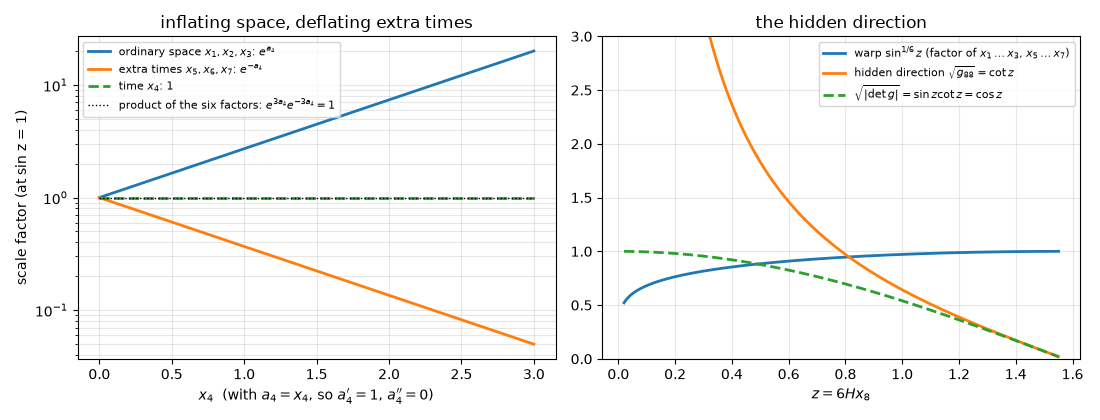

figure saved: <output>/figures/figure1_scale_factors.png | sha256 f2e19dd62b8515b200e6c6dcd46397322474848795c60faf087d8687f3252e9e


In [12]:
def save_and_show(fig, name):
    path = FIG_DIR / name
    fig.savefig(path, format="png", dpi=100, metadata={"Software": None})
    plt.close(fig)
    display(Image(data=path.read_bytes()))
    print("figure saved:", shown(path), "| sha256", sha256(path))


x4 = np.linspace(0.0, 3.0, 301)
a4 = x4
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
ax1.semilogy(x4, np.exp(a4), lw=2, label=r"ordinary space $x_1, x_2, x_3$: $e^{a_4}$")
ax1.semilogy(x4, np.exp(-a4), lw=2, label=r"extra times $x_5, x_6, x_7$: $e^{-a_4}$")
ax1.semilogy(x4, np.ones_like(x4), lw=2, ls="--", label=r"time $x_4$: 1")
ax1.semilogy(x4, np.exp(3 * a4) * np.exp(-3 * a4), lw=1, ls=":", color="k",
             label=r"product of the six factors: $e^{3a_4}e^{-3a_4} = 1$")
ax1.set_xlabel(r"$x_4$  (with $a_4 = x_4$, so $a_4' = 1$, $a_4'' = 0$)")
ax1.set_ylabel("scale factor (at sin z = 1)")
ax1.set_title("inflating space, deflating extra times")
ax1.legend(fontsize=8, loc="upper left")
ax1.grid(True, which="both", alpha=0.3)
z = np.linspace(0.02, np.pi / 2 - 0.02, 400)
ax2.plot(z, np.sin(z) ** (1 / 6), lw=2, label=r"warp $\sin^{1/6} z$ (factor of $x_1 \dots x_3$, $x_5 \dots x_7$)")
ax2.plot(z, 1 / np.tan(z), lw=2, label=r"hidden direction $\sqrt{g_{88}} = \cot z$")
ax2.plot(z, np.cos(z), lw=2, ls="--", label=r"$\sqrt{|\det g|} = \sin z \cot z = \cos z$")
ax2.set_ylim(0, 3)
ax2.set_xlabel(r"$z = 6 H x_8$")
ax2.set_title("the hidden direction")
ax2.legend(fontsize=8, loc="upper right")
ax2.grid(True, alpha=0.3)
fig.tight_layout()
save_and_show(fig, "figure1_scale_factors.png")

### 10.2 Figure 2: the normalised Lovelock components

The four independent components of $E_{(k)}$, in units of $H^{2k}$, as functions of $a_4'/H$, for
$k = 1, 2, 3$. Top row: $a_4'' = 0$ (the exponentially deflating history): the ordinary-space,
extra-time and hidden-direction curves coincide (section 8.4) and only the time component differs.
Bottom row: $a_4'' = 0.5\,H^2$: the ordinary-space and extra-time components separate, because they
contain $a_4''$ with opposite signs.

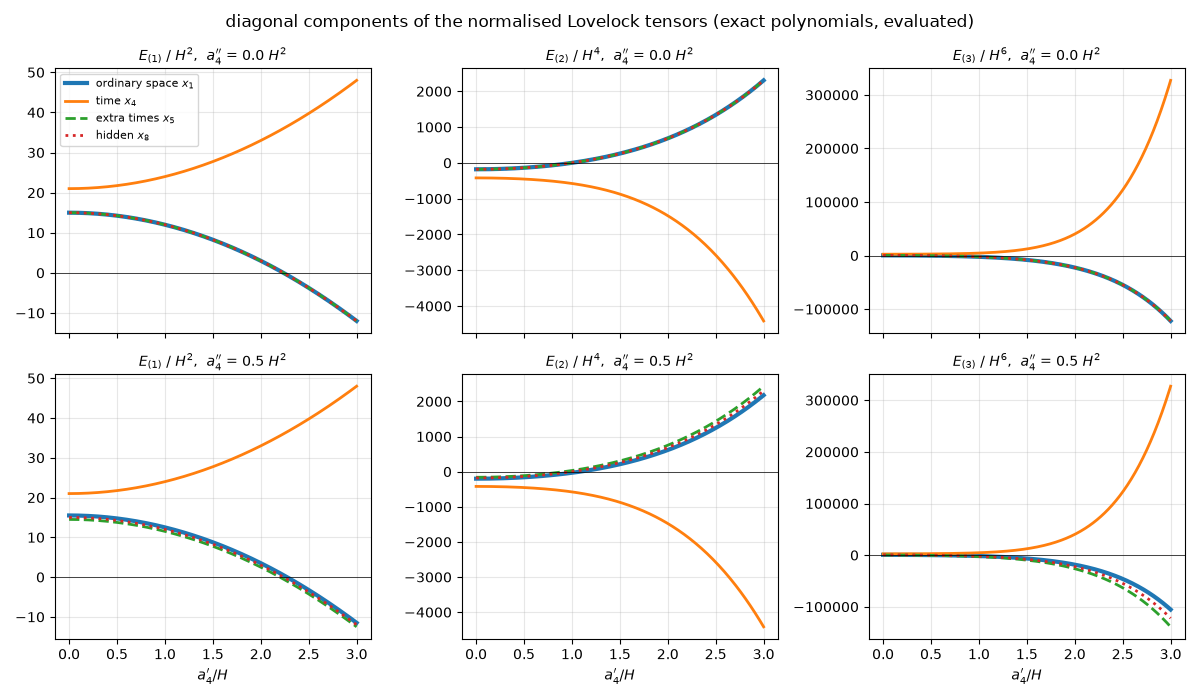

figure saved: <output>/figures/figure2_lovelock_components.png | sha256 7a180d388d97d88ae5149aa4aea9e33e0b1ad8445ef33be90332b7fb49758a42


In [13]:
def evaluate(poly, h, a1, a2):
    total = 0.0
    for m, c in poly.items():
        total = total + float(c) * h ** m[0] * a1 ** m[1] * a2 ** m[2]
    return total


u = np.linspace(0.0, 3.0, 301)
STYLE = {"x1": ("ordinary space $x_1$", "-", 3.0), "x4": ("time $x_4$", "-", 2.0),
         "x5": ("extra times $x_5$", "--", 2.0), "x8": ("hidden $x_8$", ":", 2.0)}
fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharex=True)
for row, a2 in enumerate((0.0, 0.5)):
    for col, k in enumerate((1, 2, 3)):
        ax = axes[row][col]
        for h in ("x1", "x4", "x5", "x8"):
            label, ls, lw = STYLE[h]
            ax.plot(u, evaluate(E[k][h], 1.0, u, a2), ls=ls, lw=lw, label=label)
        ax.axhline(0.0, color="k", lw=0.5)
        ax.set_title(f"$E_{{({k})}}$ / $H^{{{2 * k}}}$,  $a_4''$ = {a2} $H^2$", fontsize=10)
        ax.grid(True, alpha=0.3)
        if row == 1:
            ax.set_xlabel(r"$a_4' / H$")
axes[0][0].legend(fontsize=8)
fig.suptitle("diagonal components of the normalised Lovelock tensors (exact polynomials, evaluated)")
fig.tight_layout()
save_and_show(fig, "figure2_lovelock_components.png")

### 10.3 Figure 3: why the GKD makes the computation feasible

Left: for each order k, the number of index lists a literal sum would visit ($8^{4k+2}$), the number of
index-list leaves the program actually visits after skipping zero factors, and the number of GKD
evaluations, all from the counters of the new `lovelock-report.json`. The brute-force checks visited
all $8^6$ (k = 1) and $8^{10}$ (k = 2) lists; for k = 3, $8^{14} \approx 4.4 \times 10^{12}$ lists would be
needed. Right: the fraction of pairs of index lists of length $p$ over eight values with a non-zero
GKD, $8!/(8-p)! \cdot p!/8^{2p}$, with the exhaustive counts of section 7.2 marked; it is exactly zero
for $p = 9$.

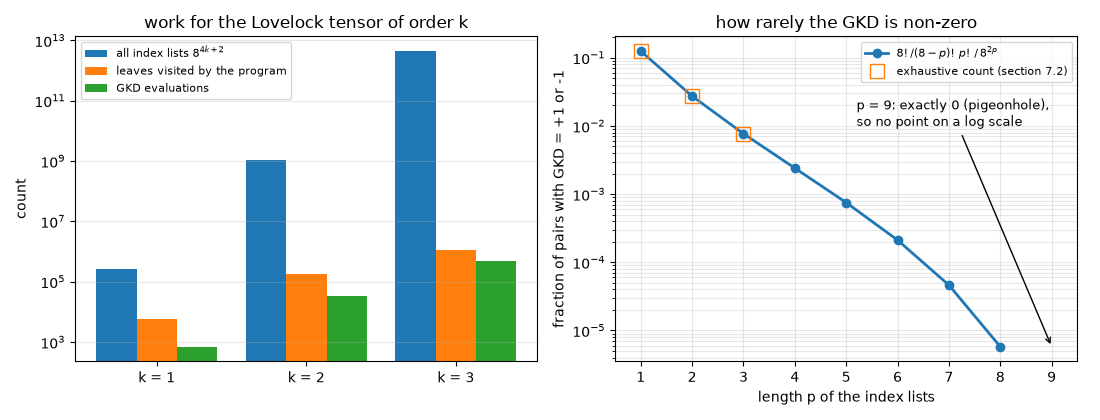

figure saved: <output>/figures/figure3_gkd_work.png | sha256 f602fb8a3078c891a31c8a6c6b2440c1c5732a10e4b42396a30ec72ff4159954
k = 1: all index lists 262144, leaves 5616, GKD evaluations 696 (non-zero 696)
k = 2: all index lists 1073741824, leaves 176640, GKD evaluations 32640 (non-zero 32640)
k = 3: all index lists 4398046511104, leaves 1128960, GKD evaluations 495360 (non-zero 495360)


In [14]:
counters = {c["k"]: c for c in new_report["counters"]}
ks = [1, 2, 3]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
width = 0.27
x = np.arange(len(ks))
ax1.bar(x - width, [8.0 ** (4 * k + 2) for k in ks], width, label=r"all index lists $8^{4k+2}$")
ax1.bar(x, [counters[k]["leaves"] for k in ks], width, label="leaves visited by the program")
ax1.bar(x + width, [counters[k]["gkdCalls"] for k in ks], width, label="GKD evaluations")
ax1.set_yscale("log")
ax1.set_xticks(x, [f"k = {k}" for k in ks])
ax1.set_ylabel("count")
ax1.set_title("work for the Lovelock tensor of order k")
ax1.legend(fontsize=8)
ax1.grid(True, axis="y", alpha=0.3)
ps = np.arange(1, 10)
fraction = [factorial(8) / factorial(8 - p) * factorial(p) / 8.0 ** (2 * p) if p <= 8 else 0.0 for p in ps]
ax2.semilogy(ps[:8], fraction[:8], "o-", lw=2, label=r"$8!/(8-p)!\,p!\,/\,8^{2p}$")
ax2.semilogy([1, 2, 3], [(OWN_GKD_COUNTS[p]["plus"] + OWN_GKD_COUNTS[p]["minus"]) / OWN_GKD_COUNTS[p]["pairs"]
                         for p in (1, 2, 3)], "s", ms=10, mfc="none", label="exhaustive count (section 7.2)")
ax2.annotate("p = 9: exactly 0 (pigeonhole),\nso no point on a log scale", xy=(9, fraction[7]),
             xytext=(5.2, 1e-2), fontsize=9, arrowprops=dict(arrowstyle="->"), annotation_clip=False)
ax2.set_xlim(0.5, 9.5)
ax2.set_xticks(list(range(1, 10)))
ax2.set_xlabel("length p of the index lists")
ax2.set_ylabel("fraction of pairs with GKD = +1 or -1")
ax2.set_title("how rarely the GKD is non-zero")
ax2.legend(fontsize=8)
ax2.grid(True, which="both", alpha=0.3)
fig.tight_layout()
save_and_show(fig, "figure3_gkd_work.png")
for k in ks:
    print(f"k = {k}: all index lists {8 ** (4 * k + 2)}, leaves {counters[k]['leaves']}, GKD evaluations "
          f"{counters[k]['gkdCalls']} (non-zero {counters[k]['gkdNonzero']})")

### 10.4 Summary of this notebook's checks

The last code cell counts the checks of this notebook (each printed a PASS line above; a failure
would have stopped the notebook at that point) and lists the files written into `<output>`.

In [15]:
print(f"checks of this notebook: {len(CHECKS)} passed, 0 failed")
for path in sorted(p for p in OUT.rglob("*") if p.is_file() and "cargo-target" not in p.parts):
    print(f"  {shown(path):48s} {path.stat().st_size:7d} bytes")

checks of this notebook: 40 passed, 0 failed
  <output>/figures/figure1_scale_factors.png         72361 bytes
  <output>/figures/figure2_lovelock_components.png  111384 bytes
  <output>/figures/figure3_gkd_work.png              57413 bytes
  <output>/lovelock_run/curvature.json               28162 bytes
  <output>/lovelock_run/lovelock-components.md       19604 bytes
  <output>/lovelock_run/lovelock-report.json          3154 bytes
  <output>/lovelock_run/lovelock-tensors.json        55056 bytes


## 11. What this notebook showed, and what it did not show

**Showed.**

- The Revision Rust program builds without warnings and recites the metric exactly as the author
  wrote it in his task.
- The generalized Kronecker delta agrees with the author's determinant definition for all pairs of
  index lists of length 1, 2 and 3 over eight values (computed here in Python), with the same counts
  of $+1$, $-1$ and $0$ as the committed Rust and Wolfram records.
- A new run of the program reproduces the four committed result files of
  `Revision/gkd_lovelock/results/` byte for byte, with all 19 of its checks passed; the committed
  sympy verification (49 checks) and Wolfram verification (29 checks) report success on input files
  whose sha256 fingerprints equal those of the files produced here.
- For the author's metric the mixed Lovelock tensors of order 1, 2 and 3 are diagonal, equal within
  ordinary space and within the extra times, free of the warp $\sin^{1/3} z$, and depend only on $H$,
  $a_4'$ and $a_4''$; the trace identities, $E_{(1)} = G$ and the density form were re-checked exactly
  in Python. The ordinary-space and extra-time components differ only through $a_4''$, so for the
  exponentially deflating history $a_4 = c\,x_4$ they coincide with the hidden-direction component.

**Did not show.**

- It does not solve the field equations for $a_4$: the Lovelock tensors are only their left sides,
  and the history $a_4 = x_4$ in Figure 1 is an illustration chosen by hand.
- It does not re-run the sympy and Wolfram verifications; it reads their committed reports and
  checks the fingerprints of their inputs.
- In its normal run it does not re-run the program's complete GKD self-test (length 4 exhaustively,
  lengths 5 to 9 by 200000 pseudo-random pairs each); that self-test is read from its committed
  record and re-run only with `REVISION_NB_LONG=1`.
- The brute-force sums cover k = 1 and k = 2 at one numerical point; for k = 3 the exactness rests on
  the program's pruned exact sum and on the two independent verifications.
- Nothing here concerns the spinor fields, their energy-momentum tensor or the dark-sector
  hypotheses.